# Part 4: Empirical Analysis

In [1]:
import sys
sys.path.insert(0, "src")

import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from vigenere import * 

In [2]:
with open("samples/alice_in_wonderland.txt") as fin:
    content = fin.read()
input_text = normalize_text(content)

In [3]:
def generate_random_key(klen):
    return ''.join([
        random.choice(alphabets)
        for _ in range(klen)
    ])

In [4]:
def select_text_window(text, window_len):
    start = random.choice(range(0, len(text)-window_len))
    return text[start:start+window_len]

In [ ]:
n_trial = 20
klen_recover_data = {}
k_recover_data = {}
alphas = [0.7, 0.8]

for klen in [3, 5, 7, 10, 15, 20]:
    for window_len in [100, 200, 500, 1000, 2000, 5000, 20000]:
        for alpha in alphas: 
            n_klen_recovered = 0
            n_key_recovered = 0

            for i in range(n_trial):
                key = generate_random_key(klen)
                window = select_text_window(input_text, window_len)
                cipher_text = encrypt_decrypt("encrypt", window, key)
                
                recovered_klen = guess_key_length(cipher_text, alpha)
                recovered_keys = guess_keys(cipher_text, recovered_klen)

                best_key = recovered_keys[0]
                recovered_klen = len(best_key)

                if recovered_klen == klen:
                    n_klen_recovered += 1
                if best_key == key:
                    n_key_recovered += 1
            
            klen_recover_data[(klen, window_len, alpha)] = n_klen_recovered / n_trial
            k_recover_data[(klen, window_len, alpha)] = n_key_recovered / n_trial

In [6]:
klen_df = pd.DataFrame({
    'klen_recover_ratio': klen_recover_data
})
klen_df.index.names = ['klen', 'window_len', 'alpha']
klen_df = klen_df.reset_index()

k_df = pd.DataFrame({
    'k_recover_ratio': k_recover_data,
})
k_df.index.names = ['klen', 'window_len', 'alpha']
k_df = k_df.reset_index()

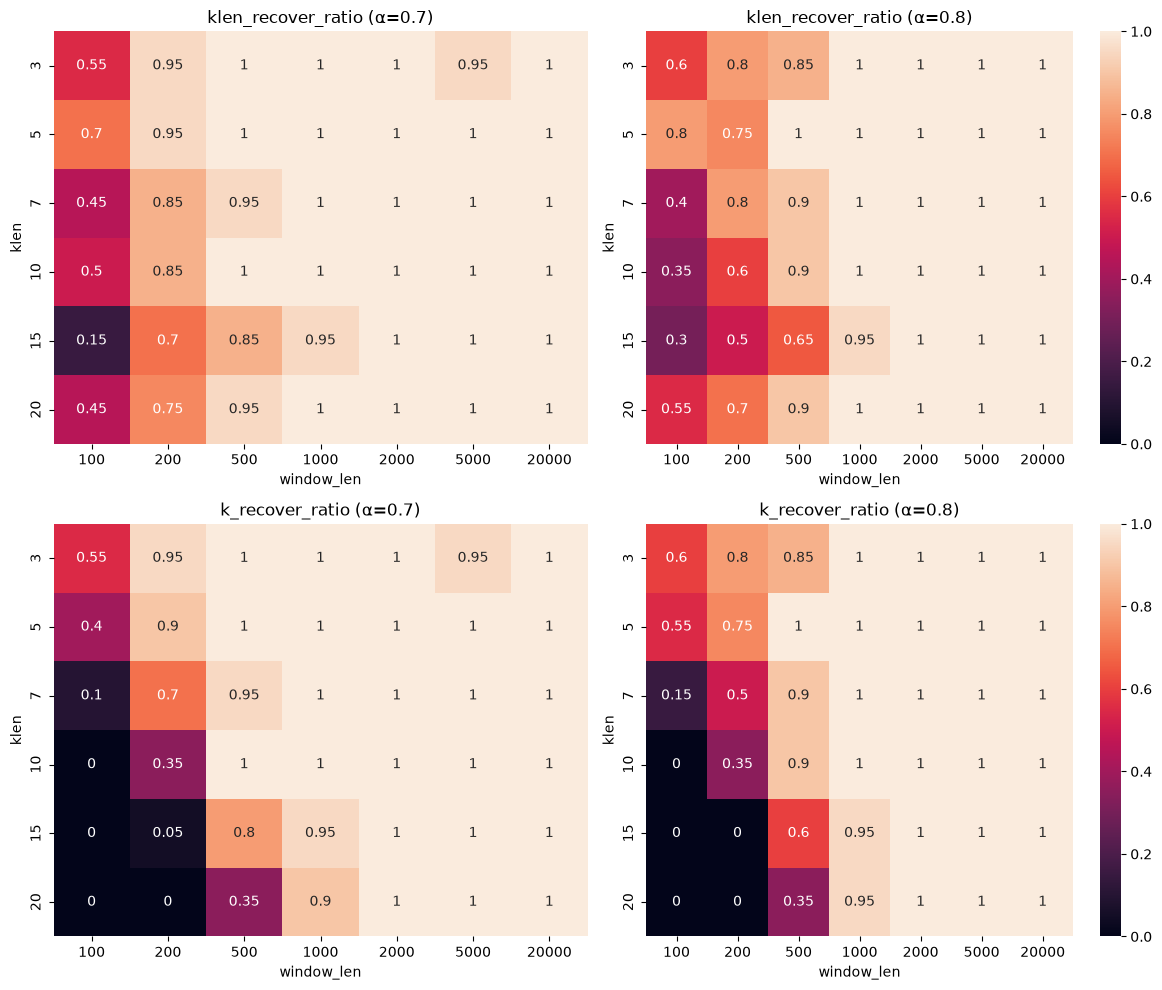

In [7]:
fig, axes = plt.subplots(2, len(alphas), figsize=(6*len(alphas), 10))

for col, alpha in enumerate(alphas):
    sub_klen = klen_df[klen_df['alpha'] == alpha]
    sub_k = k_df[k_df['alpha'] == alpha]

    pivot1 = sub_klen.pivot(index='klen', columns='window_len', values='klen_recover_ratio')
    pivot2 = sub_k.pivot(index='klen', columns='window_len', values='k_recover_ratio')

    sns.heatmap(pivot1, annot=True, ax=axes[0, col], vmin=0, vmax=1, cbar=col==len(alphas)-1)
    axes[0, col].set_title(f'klen_recover_ratio (α={alpha})')

    sns.heatmap(pivot2, annot=True, ax=axes[1, col], vmin=0, vmax=1, cbar=col==len(alphas)-1)
    axes[1, col].set_title(f'k_recover_ratio (α={alpha})')

plt.tight_layout()
plt.show()

We get the best results in the second column when $\alpha = 0.7$. $\alpha$ is a 
variable that I introduced that determines how much weight is given to IOC similarity
($\alpha = 1$) versus how well the candidate key length divides the other candidates.

Key length recovery performance is quite unreliable when cipher length is 100, 
regardless of key length; it performs somewhat better when cipher length increases 
to 200, especially when key length is longer ($\gt 10$); when cipher length is over 
200, the performance becomes fairly reliable across all key lengths. Overall, the 
algorithm performs the worst when cipher length is short while key length is long.

The algorithm behaves this way because of how IoC works. IoC estimates how closely a 
column's letter distribution matches that of English. If a candidate key length is 
the true key length, then in the resulting matrix, every letter in the same column 
is shifted by the same key letter.

If we assume that the original column conforms to a typical English letter 
distribution, then its IOC should be the same after the shift as well. Then, how 
close the column's IoC is to English IoC can be used as a proxy for whether the key 
guess is good. When the column does not conform to the English distribution 
(e.g., when there aren't enough letters), IoC works poorly.

Therefore, when the real key length is long, the matrix is stretched wide and shallow.
In this case, we would also end up with few letters in each column, which is also bad
for IOC analysis. 

Key recovery fails at the same boundary as key length recovery, since key recovery
guesses the key using the given key length produced by key length recovery.

# Part 5: Written questions

## Long keys

This sounds like an one-time cipher, **iff** the key is: 
1. Chosen perfectly uniformly randomly.
2. Never reused.
3. Not known by adversary.  

If all these conditions are satisfied, then the key is going to be substantially more secure. This is because:

> (P stands for plaintext, K for key, C for ciphertext). 

**To point 1**, with a short repeating key, we can construct a matrix whose individual columns still retain English-like letter IOC. On the other hand, with a key as long as the message, no groups of letters in P can be assumed to be shifted by the same letter in K. Therefore, no IOC analysis can be done to recover key length, and consequently no recovery of key content.

**To point 2**, if the key is reused, something similar to an XOR attack can be done, since both operations are reversible.

It would be something like this: 
$$
\begin{aligned}
C_{1} - C_{2}
&= (P_{1} + K) - (P_{2} + K) \\
&= P_{1} - P_{2}
\end{aligned}
$$

In this case, if two words from each message happen to line up (e.g., `THE`), then the resulting $P_{1} - P_{2}$ would be `AAA`. With a C letter and a guess of the P letter, the K letter can be recovered. Recovering one K letter wouldn't mean much (since each letter is chosen uniformly at random), but we will still have some good guess of some common words. 

**To point 3**, obviously. 

## Why IoC works

We would first fit the ciphertext into matrices whose width are each of the key lengths that we want to test. If a candidate key length is the true key length, then in the resulting matrix, every letter in the same column is shifted by the same key letter.

If we assume that the original column conforms to a typical English letter 
distribution, then its IOC should be the same after the shift as well. Then, how close the column's IoC is to English IoC can be used as a proxy for whether the key length guess is good.

If a candidate length is not correct, then we would have cipher letters shifted by different key letters ending up in the same column. In this case, whether two letters coincide becomes mostly a matter of chance, which is why the IOC would be closer to 0.038.

When $k$ is a *multiple* (say $n$) of the true key length, the matrix is stretched $n$ times wider than it needs to be, and the amount of letters in each column is $n$ times less. These column letters are still shifted by the same key, so the column's expected IoC is gonna be close to what it would be at the true key length. 

This means several candidate key lengths (the true length and its multiples) can end up with similar IoC scores. Among them, we want to pick the shortest one from the "group" with IOC closest to English IOC. 

## Kasiski vs. IoC

Kasiski's method is based on the assumption that if the plaintext is long enough there's a chance that the same word in the plaintext is encrypted with the same portion of the key, thus resulting the same ciphertext segments. It therefore looks for these repetitions in the ciphertext and compute the distance between them. These distances are very likely a multiple of the true key length. Then, with different groups of such repetitions, we can find the most common divisor of all these distances (excluding ones that are too short, such as 1 or 2 or 3, not only because they are unrealistically short but also because they are likely to win the divisor metric all the time), which could be a decent guess of the true key length. 

- Kasiski would out-perform IOC when the true key is when the ciphertext is long enough to contain a few repeats, but with a key length long enough that IoC's per-column data is still too sparse.

- IOC would out-perform Kasiski when not enough good repetitions happen (plaintext words unluckily do not repeat at the key length intervals). 

## IoC as a fitness function: breaking the Enigma plugboard

1. Enigma text is essentially random letters, so its IOC would be close to that of uniformly randomly selected text ($\approx$ 0.038). When the IOC score goes up, it means that the text is looking less random and have a distribution more like real English text. It is an OK fitness score because we just want to know if the new plug combination makes the ciphertext's letter distribution more English-like (or any other real langauge, in the text German). 
2. Once several cables are plugged correctly, the frequency distribution of letters are going to be somewhat close to that of a real language, and will stay around there with more trials. However, it does not care about the ordering of these letters. Bigrams and trigrams care about the ordering. They could not be used for the first pass since the likelihood of
connected word fragment appearing in that stage is extremely low. It is mostly unlikely that a sequence of three letters would appear in the text again and again purely by chance (which means that the decoding is revealing the real plaintext). Therefore, using trigrams from the very start would result in very low trigram scores for groups of letters that just happen to be together by chance, so the scoring result means essentially nothing.
3. They are used the same in that both are used to measure how similar the letter distribution of the current ciphertext is to a real language, which is just a proxy of how likely the current decoding is close or far-off. On the other hand, they are differently in that in Vigenere IOC was calculated against the ciphertext for each possible key length and there will be a best score, which we pick as the answer. For hillclimbing it is less deterministic because there would not be a solid best score, and it is just a crude metric and greedy approach for guessing whether the current plugging choice is gonna make us better off. 